# Process Performance Map (U-ED-LSTM Sepsis)

Visualizes model prediction performance overlaid on a process map.

- **Start node**: How many cases start with each activity
- **Node color**: Overall accuracy when predicting from this activity
- **Edge color**: Accuracy for this specific transition (green = high, red = low)
- **Edge label**: correct/total predictions

In [1]:
# Setup
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

import torch
from src.interpretability.config.sepsis_config import CONFIG
CONFIG.use_improved = True  # set True for the improved variant
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability.visualization.process_performance_map import ProcessPerformanceMap

print(f"Dataset: {CONFIG.dataset_name}")

Dataset: Sepsis


In [2]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    
    all_cat=CONFIG.all_cat,
    all_num=CONFIG.all_num
)

print(f"Loaded {len(test_dataset)} samples")
print(f"Available cases: {len(eval_helper.cases)}")

Data set categories:  ([('concept:name', 18, {'Admission IC': 1, 'Admission NC': 2, 'CRP': 3, 'EOS': 4, 'ER Registration': 5, 'ER Sepsis Triage': 6, 'ER Triage': 7, 'IV Antibiotics': 8, 'IV Liquid': 9, 'LacticAcid': 10, 'Leucocytes': 11, 'Release A': 12, 'Release B': 13, 'Release C': 14, 'Release D': 15, 'Release E': 16, 'Return ER': 17}), ('InfectionSuspected', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('org:group', 27, {'?': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'E': 6, 'EOS': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'J': 12, 'K': 13, 'L': 14, 'M': 15, 'N': 16, 'O': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26}), ('DiagnosticBlood', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('DisfuncOrg', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('SIRSCritTachypnea', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('Hypotensie', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('SIRSCritHeartRate', 5, {'EOS': 1, 'False': 2, 'True': 3, nan: 4}), ('Infusion'

In [3]:
# Collect predictions
ppm = ProcessPerformanceMap(
    model=model,
    test_dataset=test_dataset,
    eval_helper=eval_helper,
    activity_key=CONFIG.concept_name,
    device=device
)

ppm.collect_predictions(show_progress=True)


Collected 2798 predictions
Found 92 unique transitions


In [4]:
# --- Overall accuracy summary ---
from collections import Counter, defaultdict
import pandas as pd

preds = ppm.predictions
n_total = len(preds)
n_correct = sum(1 for p in preds if p.correct)
overall = n_correct / n_total if n_total else 0.0
print(f'Overall next-activity accuracy: {n_correct}/{n_total} = {overall:.4f} ({overall*100:.2f}%)')

# Per prefix-length
by_plen = defaultdict(lambda: {'total': 0, 'correct': 0})
for p in preds:
    by_plen[p.prefix_length]['total'] += 1
    by_plen[p.prefix_length]['correct'] += int(p.correct)
rows = [{'prefix_length': pl, 'correct': v['correct'], 'total': v['total'],
         'accuracy': v['correct'] / v['total']}
        for pl, v in sorted(by_plen.items())]
print('\nPer prefix-length:')
print(pd.DataFrame(rows).to_string(index=False))

# Mean confidence (softmax argmax prob at the predicted class)
mean_conf = sum(p.confidence for p in preds) / n_total if n_total else 0.0
print(f'\nMean top-1 confidence: {mean_conf*100:.2f}%')


Overall next-activity accuracy: 1148/2798 = 0.4103 (41.03%)

Per prefix-length:
 prefix_length  correct  total  accuracy
             1      184    209  0.880383
             2      143    209  0.684211
             3       10    209  0.047847
             4        4    199  0.020101
             5       28    199  0.140704
             6       29    181  0.160221
             7       75    177  0.423729
             8      104    173  0.601156
             9       53    146  0.363014
            10       68    138  0.492754
            11       39    124  0.314516
            12       47    120  0.391667
            13       49    102  0.480392
            14       36     86  0.418605
            15       36     67  0.537313
            16       28     56  0.500000
            17       30     44  0.681818
            18       24     39  0.615385
            19       20     34  0.588235
            20       13     31  0.419355
            21       14     26  0.538462
            22    

In [5]:
# --- Per-transition breakdown table ---
# Source activity x actual next activity, with correct/total/accuracy. This makes
# explicit which directly-follows transitions the model handles well vs. badly.
import pandas as pd
from collections import defaultdict

_stats = defaultdict(lambda: {'total': 0, 'correct': 0})
for _p in ppm.predictions:
    _key = (_p.current_activity, _p.actual_next_activity)
    _stats[_key]['total'] += 1
    _stats[_key]['correct'] += int(_p.correct)

transitions_df = pd.DataFrame([
    {'source': s, 'target': t, 'correct': v['correct'], 'total': v['total'],
     'accuracy': v['correct'] / v['total']}
    for (s, t), v in _stats.items()
]).sort_values(['source', 'total'], ascending=[True, False]).reset_index(drop=True)

print(f'{len(transitions_df)} unique transitions')
with pd.option_context('display.max_rows', None):
    display(transitions_df)


92 unique transitions


,source,target,correct,total,accuracy
0,Admission IC,LacticAcid,0,9,0.000000
1,Admission IC,CRP,6,7,0.857143
2,Admission IC,Leucocytes,0,3,0.000000
3,Admission NC,Leucocytes,27,77,0.350649
4,Admission NC,CRP,26,65,0.400000
5,Admission NC,Admission NC,12,30,0.400000
6,Admission NC,Release A,11,25,0.440000
7,Admission NC,IV Liquid,0,5,0.000000
8,Admission NC,Release B,0,4,0.000000
9,Admission NC,LacticAcid,0,3,0.000000


In [6]:
# Create activity name mapping
label_dict = ppm.get_activity_label_dict()
activity_name_map = {str(idx): name for name, idx in label_dict.items()}

print("Activity mapping:")
for idx_str in sorted(activity_name_map.keys(), key=lambda x: int(x) if x.isdigit() else 0):
    print(f"  {idx_str}: {activity_name_map[idx_str]}")

Activity mapping:
  1: Admission IC
  2: Admission NC
  3: CRP
  4: EOS
  5: ER Registration
  6: ER Sepsis Triage
  7: ER Triage
  8: IV Antibiotics
  9: IV Liquid
  10: LacticAcid
  11: Leucocytes
  12: Release A
  13: Release B
  14: Release C
  15: Release D
  16: Release E
  17: Return ER


## Process Map

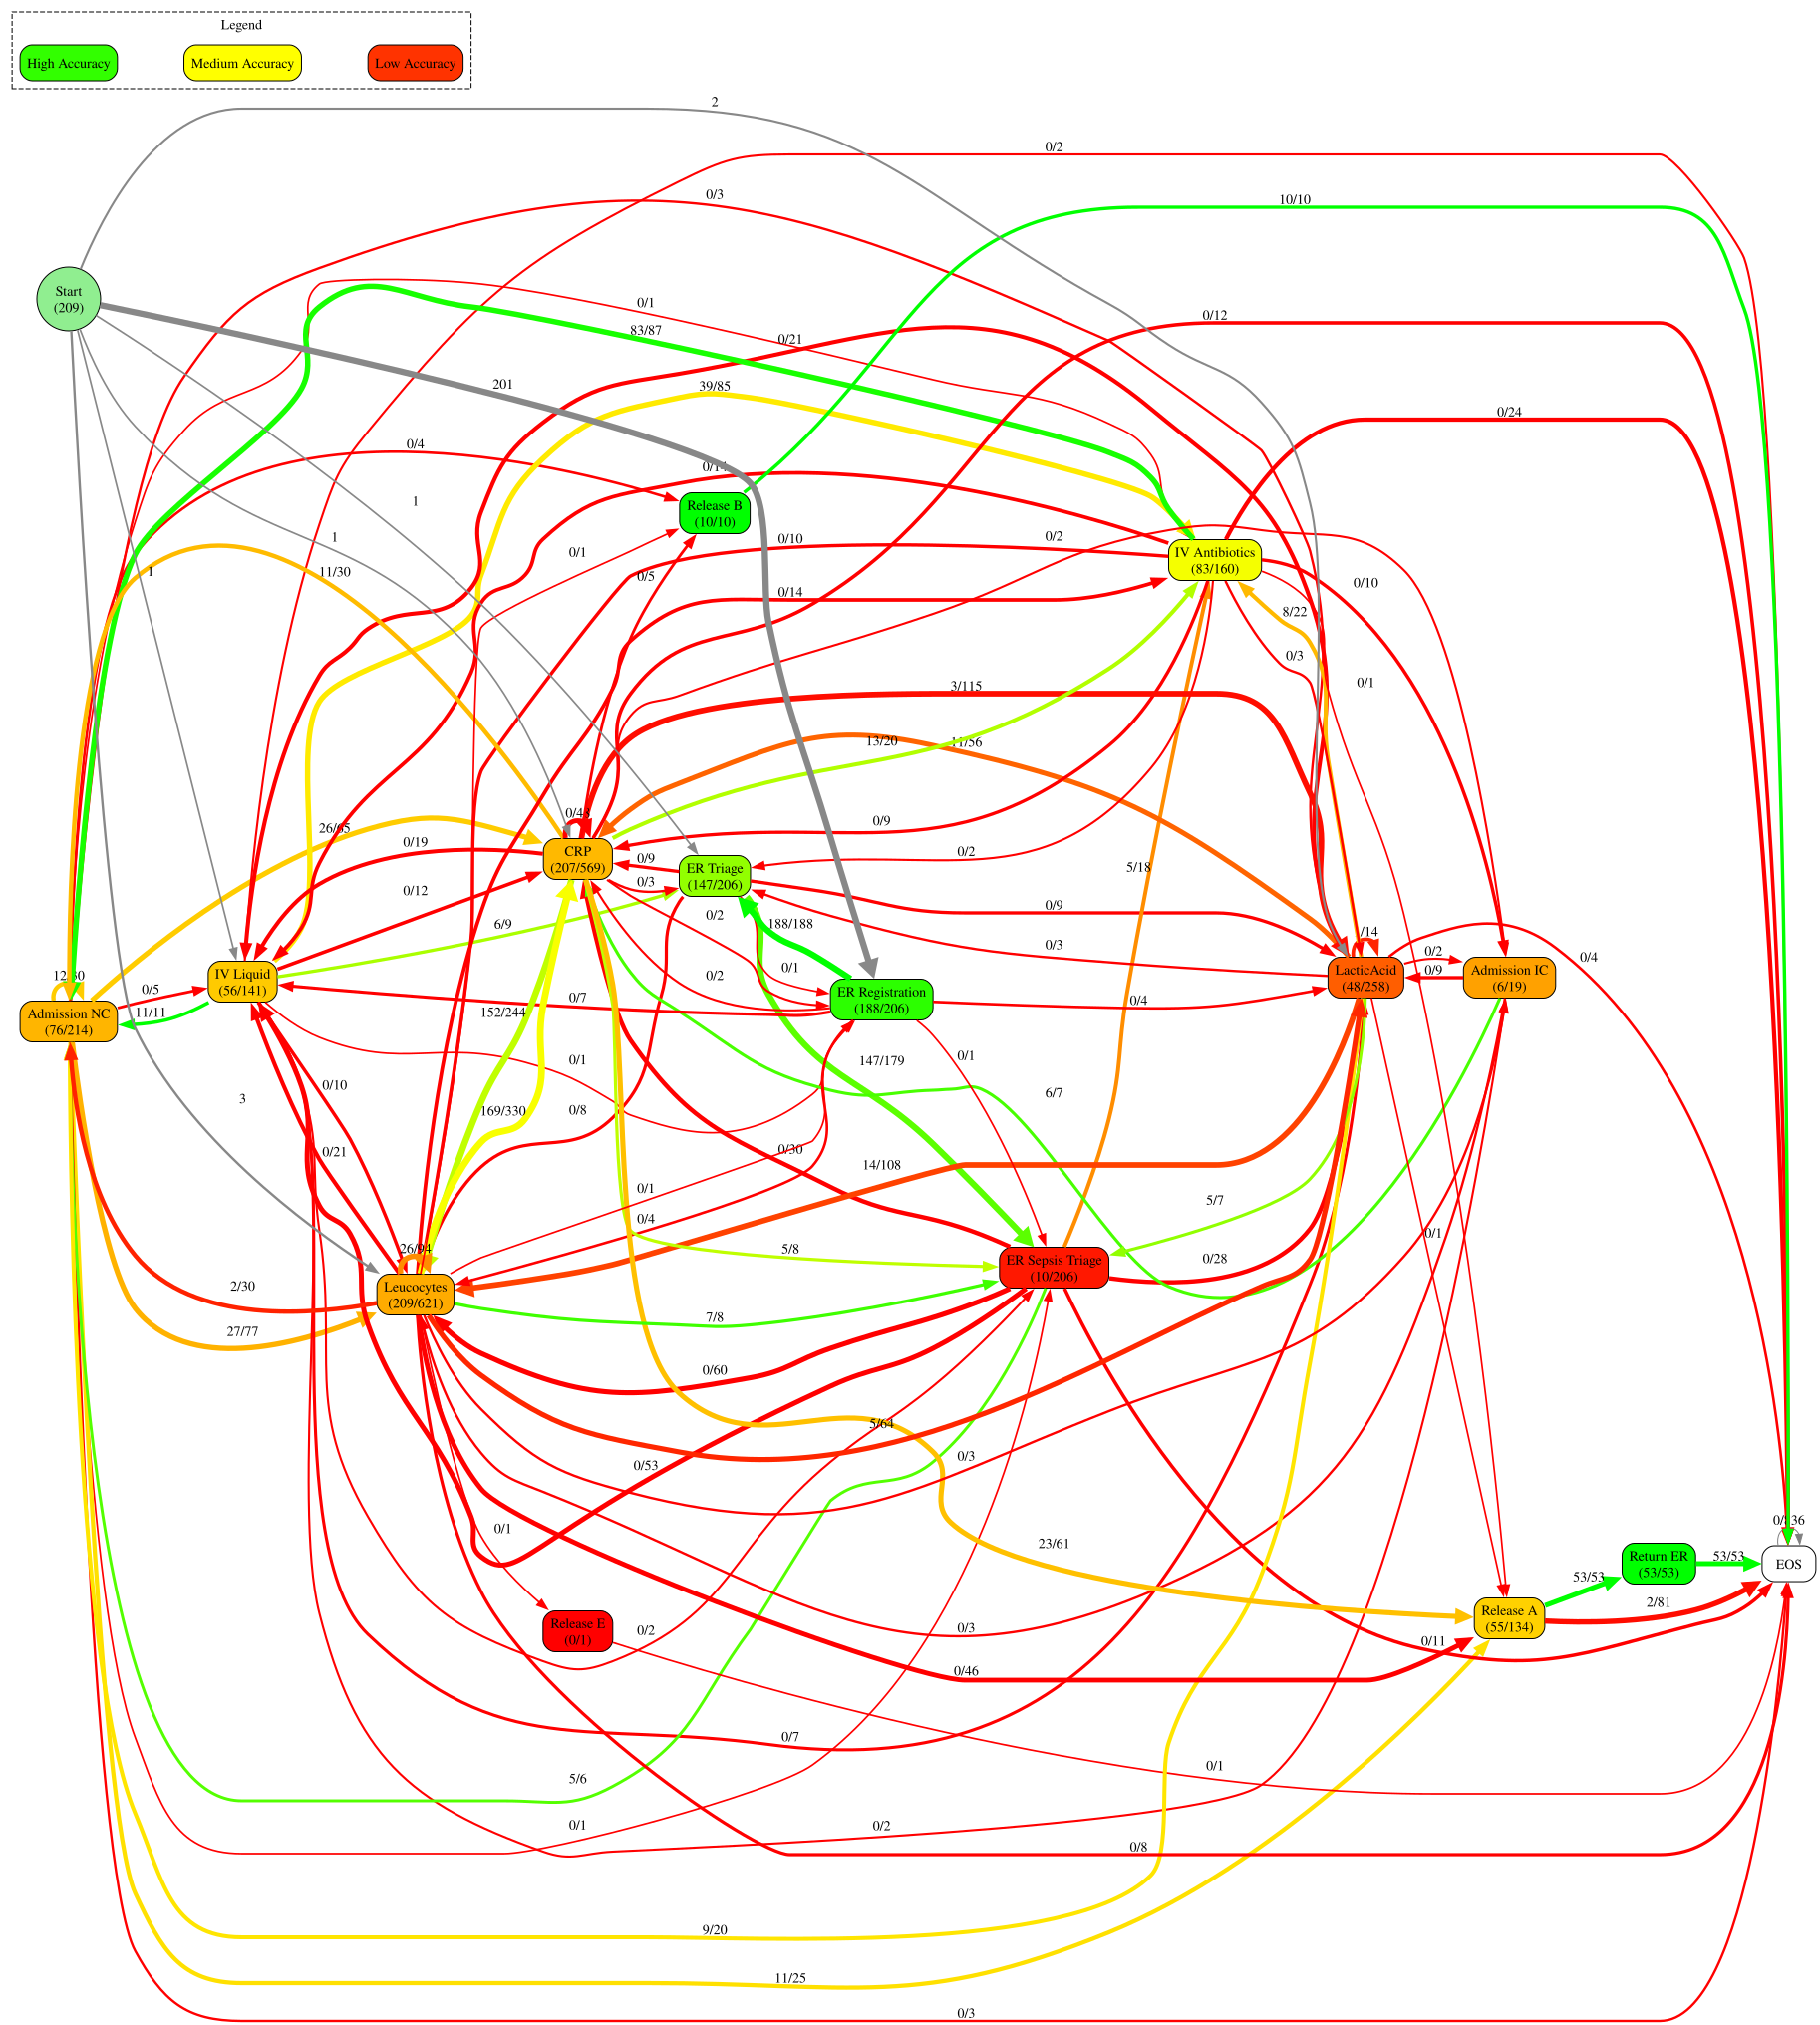

In [7]:
# Generate process map
dot = ppm.visualize(
    min_edge_count=1,
    show_counts=True,
    activity_name_map=activity_name_map,
    show_start_node=True
)
dot

## Interactive Explorer

In [8]:
# Interactive exploration
explorer = ppm.create_interactive_explorer(activity_name_map=activity_name_map)
explorer.show()